In [ ]:
from pathlib import Path
import os
import sys
import importlib.util
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

try:
    from google.colab import drive
    MOUNT = Path("/content/gdrive_maps")
    MOUNT.mkdir(parents=True, exist_ok=True)
    drive.mount(str(MOUNT), force_remount=False)
except Exception as e:
    print("Drive mount note:", e)

try:
    import geopandas as gpd
    from shapely.geometry import Point
    geopandas_status = "available"
    geopandas_error = ""
except Exception as e:
    gpd = None
    Point = None
    geopandas_status = "not available"
    geopandas_error = str(e)

package_status = pd.DataFrame([
    {"package": "pandas", "status": "available", "version": pd.__version__},
    {"package": "numpy", "status": "available", "version": np.__version__},
    {"package": "matplotlib", "status": "available", "version": importlib.import_module("matplotlib").__version__},
    {"package": "geopandas", "status": geopandas_status, "version": getattr(gpd, "__version__", "") if gpd is not None else geopandas_error},
])

def find_project_folder():
    direct_candidates = [
        Path("/content/gdrive_maps/MyDrive/STAT596/Project596_datafiles"),
        Path("/content/gdrive_results/MyDrive/STAT596/Project596_datafiles"),
        Path("/content/drive/MyDrive/STAT596/Project596_datafiles"),
    ]

    for path in direct_candidates:
        if path.exists():
            return path

    search_roots = [
        Path("/content/gdrive_maps"),
        Path("/content/gdrive_results"),
        Path("/content/drive"),
    ]

    for root in search_roots:
        if root.exists():
            for current_root, dirs, files in os.walk(root):
                current_path = Path(current_root)
                if current_path.name == "Project596_datafiles":
                    return current_path
                depth = len(current_path.relative_to(root).parts)
                if depth >= 6:
                    dirs[:] = []

    raise FileNotFoundError("Could not find Project596_datafiles. Check Drive mount or folder name.")

DATA_RAW = find_project_folder()
DATA_PROCESSED = DATA_RAW / "processed_data"
FIGURES = DATA_RAW / "figures"
TABLES = DATA_RAW / "tables"
NOTEBOOKS = DATA_RAW / "notebooks"
REPORT_READY = DATA_RAW / "report_ready_results"

for folder in [DATA_PROCESSED, FIGURES, TABLES, NOTEBOOKS, REPORT_READY]:
    folder.mkdir(parents=True, exist_ok=True)

expected_inputs = [
    "processed_data/beach_activity_station_analysis_ready.csv",
    "processed_data/beach_monitoring_stations_clean.csv",
    "processed_data/h2s_daily_environmental_analysis_ready.csv",
    "processed_data/h2s_rtma_environmental_analysis_ready.csv",
    "processed_data/daily_environmental_analysis_ready.csv",
]

expected_status = []
for rel_path in expected_inputs:
    path = DATA_RAW / rel_path
    expected_status.append({
        "expected_file": rel_path,
        "exists": path.exists(),
        "path": str(path)
    })

spatial_extensions = {".shp", ".geojson", ".json", ".gpkg", ".zip", ".kml", ".kmz"}
keywords = [
    "census", "tract", "tiger", "boundary", "boundaries",
    "beach", "station", "h2s", "river", "tijuana",
    "geojson", "shapefile", "shape", "spatial", "map"
]

candidate_rows = []
for path in DATA_RAW.rglob("*"):
    if path.is_file():
        name_lower = path.name.lower()
        suffix_match = path.suffix.lower() in spatial_extensions
        keyword_match = any(keyword in name_lower for keyword in keywords)
        if suffix_match or keyword_match:
            candidate_rows.append({
                "file_name": path.name,
                "suffix": path.suffix,
                "folder": str(path.parent.relative_to(DATA_RAW)),
                "full_path": str(path)
            })

candidate_files = pd.DataFrame(candidate_rows).sort_values(["folder", "file_name"]).reset_index(drop=True)

print("Notebook 11 setup complete")
print("=" * 70)
print("DATA_RAW:", DATA_RAW)
print("DATA_PROCESSED:", DATA_PROCESSED)
print("FIGURES:", FIGURES)
print("TABLES:", TABLES)
print("NOTEBOOKS:", NOTEBOOKS)
print("REPORT_READY:", REPORT_READY)

print("\nPackage status")
display(package_status)

print("\nExpected input file check")
display(pd.DataFrame(expected_status))

print("\nPossible spatial/map-related candidate files")
print("Candidate file count:", len(candidate_files))
display(candidate_files.head(100))

Mounted at /content/gdrive_maps
Notebook 11 setup complete
DATA_RAW: /content/gdrive_maps/MyDrive/STAT596/Project596_datafiles
DATA_PROCESSED: /content/gdrive_maps/MyDrive/STAT596/Project596_datafiles/processed_data
FIGURES: /content/gdrive_maps/MyDrive/STAT596/Project596_datafiles/figures
TABLES: /content/gdrive_maps/MyDrive/STAT596/Project596_datafiles/tables
NOTEBOOKS: /content/gdrive_maps/MyDrive/STAT596/Project596_datafiles/notebooks
REPORT_READY: /content/gdrive_maps/MyDrive/STAT596/Project596_datafiles/report_ready_results

Package status


,package,status,version
0,pandas,available,2.2.2
1,numpy,available,2.0.2
2,matplotlib,available,3.10.0
3,geopandas,available,1.1.3



Expected input file check


,expected_file,exists,path
0,processed_data/beach_activity_station_analysis...,True,/content/gdrive_maps/MyDrive/STAT596/Project59...
1,processed_data/beach_monitoring_stations_clean...,True,/content/gdrive_maps/MyDrive/STAT596/Project59...
2,processed_data/h2s_daily_environmental_analysi...,True,/content/gdrive_maps/MyDrive/STAT596/Project59...
3,processed_data/h2s_rtma_environmental_analysis...,True,/content/gdrive_maps/MyDrive/STAT596/Project59...
4,processed_data/daily_environmental_analysis_re...,True,/content/gdrive_maps/MyDrive/STAT596/Project59...



Possible spatial/map-related candidate files
Candidate file count: 55


,file_name,suffix,folder,full_path
0,beach-advisories.csv,.csv,.,/content/gdrive_maps/MyDrive/STAT596/Project59...
1,beach-information-csv.csv,.csv,.,/content/gdrive_maps/MyDrive/STAT596/Project59...
2,beach-monitoring-stations.csv,.csv,.,/content/gdrive_maps/MyDrive/STAT596/Project59...
3,beach-watch-data-dictionary.pdf,.pdf,.,/content/gdrive_maps/MyDrive/STAT596/Project59...
4,h2s_clean_2024_2025.csv,.csv,.,/content/gdrive_maps/MyDrive/STAT596/Project59...
5,h2s_rtma_full_matched_60_events.csv,.csv,.,/content/gdrive_maps/MyDrive/STAT596/Project59...
6,sd_beach_advisories_clean_2023_latest.csv,.csv,.,/content/gdrive_maps/MyDrive/STAT596/Project59...
7,sd_census_tracts_clean.geojson,.geojson,.,/content/gdrive_maps/MyDrive/STAT596/Project59...
8,sd_census_tracts_clean_attributes.csv,.csv,.,/content/gdrive_maps/MyDrive/STAT596/Project59...
9,south_bay_census_tracts.geojson,.geojson,.,/content/gdrive_maps/MyDrive/STAT596/Project59...


In [ ]:
# prepares census tracts, beach stations, beach activity, and H2S stations for maps.

from pathlib import Path
import pandas as pd
import numpy as np

if gpd is None:
    raise ImportError("geopandas is not available. Run: !pip install geopandas")

def find_col(df, options):
    cols_lower = {c.lower(): c for c in df.columns}
    for option in options:
        if option.lower() in cols_lower:
            return cols_lower[option.lower()]
    return None

def make_points(df, lon_options, lat_options, crs="EPSG:4326"):
    lon_col = find_col(df, lon_options)
    lat_col = find_col(df, lat_options)

    if lon_col is None or lat_col is None:
        return None, lon_col, lat_col

    clean = df.copy()
    clean[lon_col] = pd.to_numeric(clean[lon_col], errors="coerce")
    clean[lat_col] = pd.to_numeric(clean[lat_col], errors="coerce")
    clean = clean.dropna(subset=[lon_col, lat_col])

    gdf = gpd.GeoDataFrame(
        clean,
        geometry=gpd.points_from_xy(clean[lon_col], clean[lat_col]),
        crs=crs
    )

    return gdf, lon_col, lat_col

paths = {
    "sd_census": DATA_RAW / "sd_census_tracts_clean.geojson",
    "south_bay_census": DATA_RAW / "south_bay_census_tracts.geojson",
    "south_bay_proximity": DATA_PROCESSED / "south_bay_census_tracts_proximity.geojson",
    "beach_stations": DATA_PROCESSED / "beach_monitoring_stations_clean.csv",
    "beach_activity": DATA_PROCESSED / "beach_activity_station_analysis_ready.csv",
    "h2s_daily": DATA_PROCESSED / "h2s_daily_environmental_analysis_ready.csv",
    "h2s_rtma": DATA_PROCESSED / "h2s_rtma_environmental_analysis_ready.csv",
}

path_check = pd.DataFrame([
    {"name": name, "exists": path.exists(), "path": str(path)}
    for name, path in paths.items()
])

display(path_check)

sd_census = gpd.read_file(paths["sd_census"]) if paths["sd_census"].exists() else None
south_bay_census = gpd.read_file(paths["south_bay_census"]) if paths["south_bay_census"].exists() else None
south_bay_proximity = gpd.read_file(paths["south_bay_proximity"]) if paths["south_bay_proximity"].exists() else None

beach_stations = pd.read_csv(paths["beach_stations"]) if paths["beach_stations"].exists() else None
beach_activity = pd.read_csv(paths["beach_activity"]) if paths["beach_activity"].exists() else None
h2s_daily = pd.read_csv(paths["h2s_daily"]) if paths["h2s_daily"].exists() else None
h2s_rtma = pd.read_csv(paths["h2s_rtma"]) if paths["h2s_rtma"].exists() else None

beach_points, beach_lon_col, beach_lat_col = make_points(
    beach_stations,
    ["station_lon", "longitude", "lon", "x"],
    ["station_lat", "latitude", "lat", "y"]
) if beach_stations is not None else (None, None, None)

h2s_points, h2s_lon_col, h2s_lat_col = make_points(
    h2s_rtma,
    ["station_lon", "longitude", "lon", "x"],
    ["station_lat", "latitude", "lat", "y"]
) if h2s_rtma is not None else (None, None, None)

summary_rows = []

for name, obj in [
    ("sd_census", sd_census),
    ("south_bay_census", south_bay_census),
    ("south_bay_proximity", south_bay_proximity),
    ("beach_stations", beach_stations),
    ("beach_activity", beach_activity),
    ("h2s_daily", h2s_daily),
    ("h2s_rtma", h2s_rtma),
    ("beach_points", beach_points),
    ("h2s_points", h2s_points),
]:
    if obj is None:
        summary_rows.append({"dataset": name, "loaded": False, "rows": 0, "columns": 0, "crs": ""})
    else:
        crs_value = str(obj.crs) if hasattr(obj, "crs") else ""
        summary_rows.append({"dataset": name, "loaded": True, "rows": len(obj), "columns": len(obj.columns), "crs": crs_value})

qa_summary = pd.DataFrame(summary_rows)

print("Loaded input QA")
display(qa_summary)

print("Beach point coordinate columns:", beach_lon_col, beach_lat_col)
print("H2S point coordinate columns:", h2s_lon_col, h2s_lat_col)

if beach_stations is not None:
    print("\nBeach station columns")
    print(list(beach_stations.columns))

if beach_activity is not None:
    print("\nBeach activity columns")
    print(list(beach_activity.columns))

if h2s_rtma is not None:
    print("\nH2S RTMA columns")
    print(list(h2s_rtma.columns))

if south_bay_proximity is not None:
    print("\nSouth Bay proximity columns")
    print(list(south_bay_proximity.columns))

,name,exists,path
0,sd_census,True,/content/gdrive_maps/MyDrive/STAT596/Project59...
1,south_bay_census,True,/content/gdrive_maps/MyDrive/STAT596/Project59...
2,south_bay_proximity,True,/content/gdrive_maps/MyDrive/STAT596/Project59...
3,beach_stations,True,/content/gdrive_maps/MyDrive/STAT596/Project59...
4,beach_activity,True,/content/gdrive_maps/MyDrive/STAT596/Project59...
5,h2s_daily,True,/content/gdrive_maps/MyDrive/STAT596/Project59...
6,h2s_rtma,True,/content/gdrive_maps/MyDrive/STAT596/Project59...


Loaded input QA


,dataset,loaded,rows,columns,crs
0,sd_census,True,737,14,EPSG:2230
1,south_bay_census,True,263,14,EPSG:2230
2,south_bay_proximity,True,263,29,EPSG:4326
3,beach_stations,True,284,34,
4,beach_activity,True,12915,67,
5,h2s_daily,True,59,96,
6,h2s_rtma,True,60,134,
7,beach_points,True,284,35,EPSG:4326
8,h2s_points,False,0,0,


Beach point coordinate columns: station_lon station_lat
H2S point coordinate columns: None None

Beach station columns
['station_id', 'station_agency_id', 'beach_name_id', 'station_name', 'station_description', 'agency_station_identifier', 'beach_name', 'beach_type', 'nearest_city', 'water_body_name', 'water_body_class', 'water_body_type', 'watershed_name', 'ab411_beach', 'usepa_id', 'beach_access', 'county', 'county_name', 'station_status', 'beach_status', 'agency_name', 'agency_jurisdiction', 'regional_board', 'regional_board_name', 'station_lat', 'station_lon', 'coordinate_source', 'beach_upper_lat', 'beach_upper_lon', 'beach_lower_lat', 'beach_lower_lon', 'beach_mid_lat', 'beach_mid_lon', 'valid_station_point']

Beach activity columns
['date', 'beach_event_id', 'start_date', 'end_date', 'start_date_clipped', 'end_date_clipped', 'duration_days_clean', 'analysis_period', 'post_emergency', 'study_group', 'impact_level', 'advisory_type_clean', 'advisory_cause_clean', 'source_clean', 'c

In [ ]:
TARGET_CRS = "EPSG:4326"

sd_census_wgs = sd_census.to_crs(TARGET_CRS) if sd_census is not None else None
south_bay_census_wgs = south_bay_census.to_crs(TARGET_CRS) if south_bay_census is not None else None
south_bay_proximity_wgs = south_bay_proximity.to_crs(TARGET_CRS) if south_bay_proximity is not None else None

h2s_points, h2s_lon_col, h2s_lat_col = make_points(
    h2s_rtma,
    ["target_lon", "station_lon", "longitude", "lon", "x"],
    ["target_lat", "station_lat", "latitude", "lat", "y"]
)

beach_metric_cols = [
    "active_advisory_day",
    "closure_active_day",
    "posting_active_day",
    "bacteria_related_event",
    "tijuana_river_related_event",
    "sewage_infrastructure_event",
    "sewage_related_event"
]

beach_metric_cols = [c for c in beach_metric_cols if c in beach_activity.columns]

beach_work = beach_activity.copy()

for col in beach_metric_cols:
    beach_work[col] = pd.to_numeric(beach_work[col], errors="coerce").fillna(0)

beach_group_cols = [
    "station_id",
    "station_name",
    "station_name_clean",
    "beach_name",
    "beach_name_clean",
    "study_group",
    "impact_level",
    "station_lat",
    "station_lon"
]

beach_group_cols = [c for c in beach_group_cols if c in beach_work.columns]

beach_station_summary = (
    beach_work
    .groupby(beach_group_cols, dropna=False)[beach_metric_cols]
    .sum()
    .reset_index()
)

beach_station_summary = beach_station_summary.rename(columns={
    "active_advisory_day": "active_advisory_record_days",
    "closure_active_day": "active_closure_record_days",
    "posting_active_day": "active_posting_record_days",
    "bacteria_related_event": "active_bacteria_related_record_days",
    "tijuana_river_related_event": "active_tijuana_river_related_record_days",
    "sewage_infrastructure_event": "active_sewage_infrastructure_record_days",
    "sewage_related_event": "active_sewage_related_record_days"
})

beach_activity_points, beach_activity_lon_col, beach_activity_lat_col = make_points(
    beach_station_summary,
    ["station_lon", "longitude", "lon", "x"],
    ["station_lat", "latitude", "lat", "y"]
)

h2s_work = h2s_rtma.copy()

h2s_numeric_cols = [
    "h2s_ppb",
    "elevated_h2s_event",
    "h2s_ge_10_event",
    "orange_h2s_event",
    "wind_speed_10m_mph",
    "wind_gust_10m_mph",
    "visibility_surface_miles"
]

for col in h2s_numeric_cols:
    if col in h2s_work.columns:
        h2s_work[col] = pd.to_numeric(h2s_work[col], errors="coerce")

h2s_station_summary = (
    h2s_work
    .groupby(["location_clean", "target_lat", "target_lon"], dropna=False)
    .agg(
        h2s_event_count=("h2s_ppb", "count"),
        h2s_ge_10_event_count=("h2s_ge_10_event", "sum"),
        orange_h2s_event_count=("orange_h2s_event", "sum"),
        max_h2s_ppb=("h2s_ppb", "max"),
        mean_h2s_ppb=("h2s_ppb", "mean"),
        mean_wind_speed_mph=("wind_speed_10m_mph", "mean"),
        mean_wind_gust_mph=("wind_gust_10m_mph", "mean"),
        mean_visibility_miles=("visibility_surface_miles", "mean")
    )
    .reset_index()
)

h2s_station_points, h2s_station_lon_col, h2s_station_lat_col = make_points(
    h2s_station_summary,
    ["target_lon"],
    ["target_lat"]
)

beach_summary_path = TABLES / "notebook11_beach_station_map_summary.csv"
h2s_summary_path = TABLES / "notebook11_h2s_station_map_summary.csv"

beach_station_summary.to_csv(beach_summary_path, index=False)
h2s_station_summary.to_csv(h2s_summary_path, index=False)

layer_rows = []

for name, obj in [
    ("sd_census_wgs", sd_census_wgs),
    ("south_bay_census_wgs", south_bay_census_wgs),
    ("south_bay_proximity_wgs", south_bay_proximity_wgs),
    ("beach_activity_points", beach_activity_points),
    ("h2s_station_points", h2s_station_points),
]:
    if obj is not None:
        bounds = obj.total_bounds if hasattr(obj, "total_bounds") else [np.nan, np.nan, np.nan, np.nan]
        layer_rows.append({
            "layer": name,
            "rows": len(obj),
            "columns": len(obj.columns),
            "crs": str(obj.crs),
            "min_lon": bounds[0],
            "min_lat": bounds[1],
            "max_lon": bounds[2],
            "max_lat": bounds[3]
        })

layer_summary = pd.DataFrame(layer_rows)

print("Map-ready layer QA")
display(layer_summary)

print("Coordinate columns")
print("Beach activity points:", beach_activity_lon_col, beach_activity_lat_col)
print("H2S station points:", h2s_station_lon_col, h2s_station_lat_col)

print("\nSaved summary tables")
print(beach_summary_path)
print(h2s_summary_path)

print("\nTop beach stations by active closure record-days")
display(
    beach_station_summary
    .sort_values("active_closure_record_days", ascending=False)
    .head(10)
)

print("\nH2S station summary")
display(h2s_station_summary)

Map-ready layer QA


,layer,rows,columns,crs,min_lon,min_lat,max_lon,max_lat
0,sd_census_wgs,737,14,EPSG:4326,-117.611081,32.528832,-116.080940,33.505025
1,south_bay_census_wgs,263,14,EPSG:4326,-117.611081,32.528832,-116.668152,33.384377
2,south_bay_proximity_wgs,263,29,EPSG:4326,-117.611081,32.528832,-116.668152,33.384377
3,beach_activity_points,134,17,EPSG:4326,-117.596000,32.535950,117.596000,33.386900
4,h2s_station_points,3,12,EPSG:4326,-117.113100,32.552000,-117.043100,32.584600


Coordinate columns
Beach activity points: station_lon station_lat
H2S station points: target_lon target_lat

Saved summary tables
/content/gdrive_maps/MyDrive/STAT596/Project596_datafiles/tables/notebook11_beach_station_map_summary.csv
/content/gdrive_maps/MyDrive/STAT596/Project596_datafiles/tables/notebook11_h2s_station_map_summary.csv

Top beach stations by active closure record-days


,station_id,station_name,station_name_clean,beach_name,beach_name_clean,study_group,impact_level,station_lat,station_lon,active_advisory_record_days,active_closure_record_days,active_posting_record_days,active_bacteria_related_record_days,active_tijuana_river_related_record_days,active_sewage_infrastructure_record_days,active_sewage_related_record_days
55,455,IB-010,IB-010,Border Field State Park,Border Field State Park,South Bay / Tijuana River Impact,2,32.535950,-117.124300,1159,1159,0,1159,1159,0,1159
57,459,IB-050,IB-050,"Imperial Beach municipal beach, other","Imperial Beach municipal beach, other",South Bay / Tijuana River Impact,2,32.566577,-117.133205,1081,1081,0,943,1079,0,1079
61,461,IB-070,IB-070,Silver Strand State Beach,Silver Strand State Beach,South Bay / Tijuana River Impact,2,32.635800,-117.143170,817,817,0,565,817,0,817
2,319,EH-010,EH-010,"Imperial Beach municipal beach, other","Imperial Beach municipal beach, other",South Bay / Tijuana River Impact,2,32.572665,-117.133201,484,484,0,477,482,0,482
4,322,EH-030,EH-030,Imperial Beach pier area,Imperial Beach pier area,South Bay / Tijuana River Impact,2,32.578750,-117.133186,480,480,0,475,478,0,478
59,460,IB-060,IB-060,north Imperial Beach,north Imperial Beach,South Bay / Tijuana River Impact,2,32.585679,-117.133049,473,473,0,468,473,0,473
111,1038,IB-079,IB-079,Coronado City beaches,Coronado City beaches,South Bay / Tijuana River Impact,2,32.674066,-117.172300,455,455,0,367,455,0,455
6,325,EH-050,EH-050,Coronado City beaches,Coronado City beaches,South Bay / Tijuana River Impact,2,32.681840,-117.185260,372,372,0,104,372,0,372
8,328,EH-060,EH-060,Coronado north beach,Coronado north beach,South Bay / Tijuana River Impact,2,32.685586,-117.194319,353,353,0,180,330,2,332
63,462,IB-080,IB-080,Coronado City beaches,Coronado City beaches,South Bay / Tijuana River Impact,2,32.677500,-117.177270,103,103,0,49,103,0,103



H2S station summary


,location_clean,target_lat,target_lon,h2s_event_count,h2s_ge_10_event_count,orange_h2s_event_count,max_h2s_ppb,mean_h2s_ppb,mean_wind_speed_mph,mean_wind_gust_mph,mean_visibility_miles
0,IB CIVIC CTR,32.5846,-117.1131,9,9,0,27.9,16.222222,3.442402,5.095252,7.013641
1,NESTOR - BES,32.5790,-117.0910,31,31,7,295.6,46.154839,3.022755,4.841893,7.598066
2,SAN YSIDRO,32.5520,-117.0431,20,20,4,45.5,21.525000,2.963945,4.706522,7.996850


We created this map by loading the cleaned spatial layers from the project folder: San Diego County census tracts, the South Bay census tract layer, beach monitoring station coordinates, and H2S station coordinates. The beach stations came from the cleaned beach station metadata, while the H2S stations came from the matched H2S/RTMA dataset using target_lat and target_lon. We converted everything to the same coordinate system, EPSG:4326, so the point layers and polygon layers would line up correctly on one map.

The purpose of this map is to give spatial context for the project before showing the results. It shows that the project is not only time-based, but also spatial because beach monitoring stations, H2S monitors, census tracts, and affected communities are located in specific places across South San Diego County. The map helps the reader understand where the major monitoring locations are, especially around Imperial Beach, Nestor, San Ysidro, and the South Bay/Tijuana River impact area.

For the project, this map supports the main research question by showing the geography of the datasets being compared. It also sets up the later maps that will show beach closure intensity, H2S patterns, and community proximity patterns.

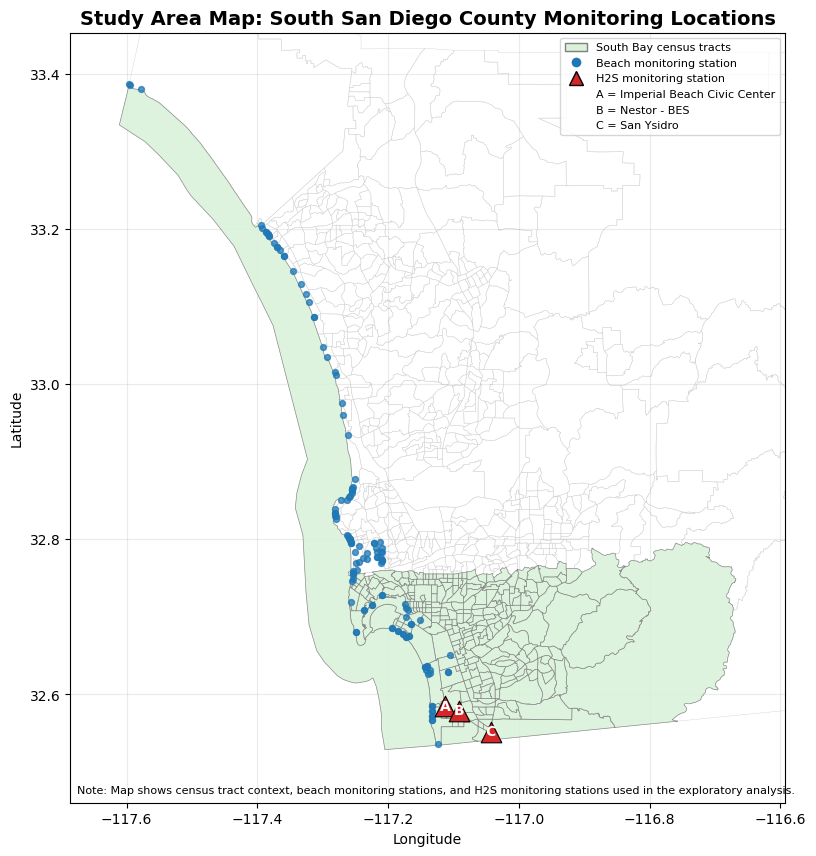

Saved figure:
/content/gdrive_maps/MyDrive/STAT596/Project596_datafiles/figures/figure_7_notebook11_study_area_map.png
File exists: True


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pathlib import Path

fig, ax = plt.subplots(figsize=(10, 10))

# Full San Diego County census tract context
if sd_census_wgs is not None:
    sd_census_wgs.plot(
        ax=ax,
        facecolor="none",
        edgecolor="lightgray",
        linewidth=0.3,
        zorder=1
    )

# South Bay census tracts highlighted in light green
if south_bay_census_wgs is not None:
    south_bay_census_wgs.plot(
        ax=ax,
        facecolor="#d9f2d9",
        edgecolor="gray",
        linewidth=0.5,
        alpha=0.85,
        zorder=2
    )

# Beach monitoring stations
if beach_activity_points is not None:
    beach_activity_points.plot(
        ax=ax,
        color="#1f77b4",
        markersize=18,
        alpha=0.75,
        zorder=4
    )

# H2S monitoring station letter labels
h2s_label_map = {
    "IB CIVIC CTR": "A",
    "NESTOR - BES": "B",
    "SAN YSIDRO": "C"
}

# Full H2S names for the legend
h2s_full_name_map = {
    "IB CIVIC CTR": "Imperial Beach Civic Center",
    "NESTOR - BES": "Nestor - BES",
    "SAN YSIDRO": "San Ysidro"
}

if h2s_station_points is not None:
    h2s_station_points = h2s_station_points.copy()
    h2s_station_points["map_label"] = h2s_station_points["location_clean"].map(h2s_label_map)

    h2s_station_points.plot(
        ax=ax,
        color="#d62728",
        markersize=220,
        marker="^",
        edgecolor="black",
        linewidth=0.8,
        zorder=5
    )

# Add A, B, C labels inside H2S station markers
if h2s_station_points is not None:
    for _, row in h2s_station_points.iterrows():
        ax.annotate(
            str(row["map_label"]),
            xy=(row.geometry.x, row.geometry.y),
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="white",
            zorder=7
        )

# Zoom to South Bay study area
bounds = south_bay_census_wgs.total_bounds
x_pad = (bounds[2] - bounds[0]) * 0.08
y_pad = (bounds[3] - bounds[1]) * 0.08

ax.set_xlim(bounds[0] - x_pad, bounds[2] + x_pad)
ax.set_ylim(bounds[1] - y_pad, bounds[3] + y_pad)

# Legend
legend_items = [
    Patch(
        facecolor="#d9f2d9",
        edgecolor="gray",
        label="South Bay census tracts"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Beach monitoring station",
        markerfacecolor="#1f77b4",
        markersize=8
    ),
    Line2D(
        [0], [0],
        marker="^",
        color="w",
        label="H2S monitoring station",
        markerfacecolor="#d62728",
        markeredgecolor="black",
        markersize=10
    )
]

for station_name, letter in h2s_label_map.items():
    full_name = h2s_full_name_map.get(station_name, station_name)
    legend_items.append(
        Line2D(
            [0], [0],
            color="w",
            label=f"{letter} = {full_name}"
        )
    )

ax.legend(
    handles=legend_items,
    loc="upper right",
    frameon=True,
    fontsize=8
)

# Titles and labels
ax.set_title(
    "Study Area Map: South San Diego County Monitoring Locations",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.text(
    0.01,
    0.01,
    "Note: Map shows census tract context, beach monitoring stations, and H2S monitoring stations used in the exploratory analysis.",
    transform=ax.transAxes,
    fontsize=8,
    va="bottom"
)

ax.grid(True, alpha=0.25)

# Save figure
figure_path = FIGURES / "figure_7_notebook11_study_area_map.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:")
print(figure_path)
print("File exists:", figure_path.exists())

Figure 7 shows the spatial layout of the project study area. The map combines South Bay census tracts, beach monitoring stations, and H2S monitoring stations in a shared geographic reference system. This figure provides spatial context for the analysis by showing that the datasets are concentrated around South San Diego County, especially near Imperial Beach, Nestor, San Ysidro, and the South Bay/Tijuana River impact area. The map supports the project’s research question by showing where water-quality monitoring, air-quality monitoring, and nearby communities overlap geographically.

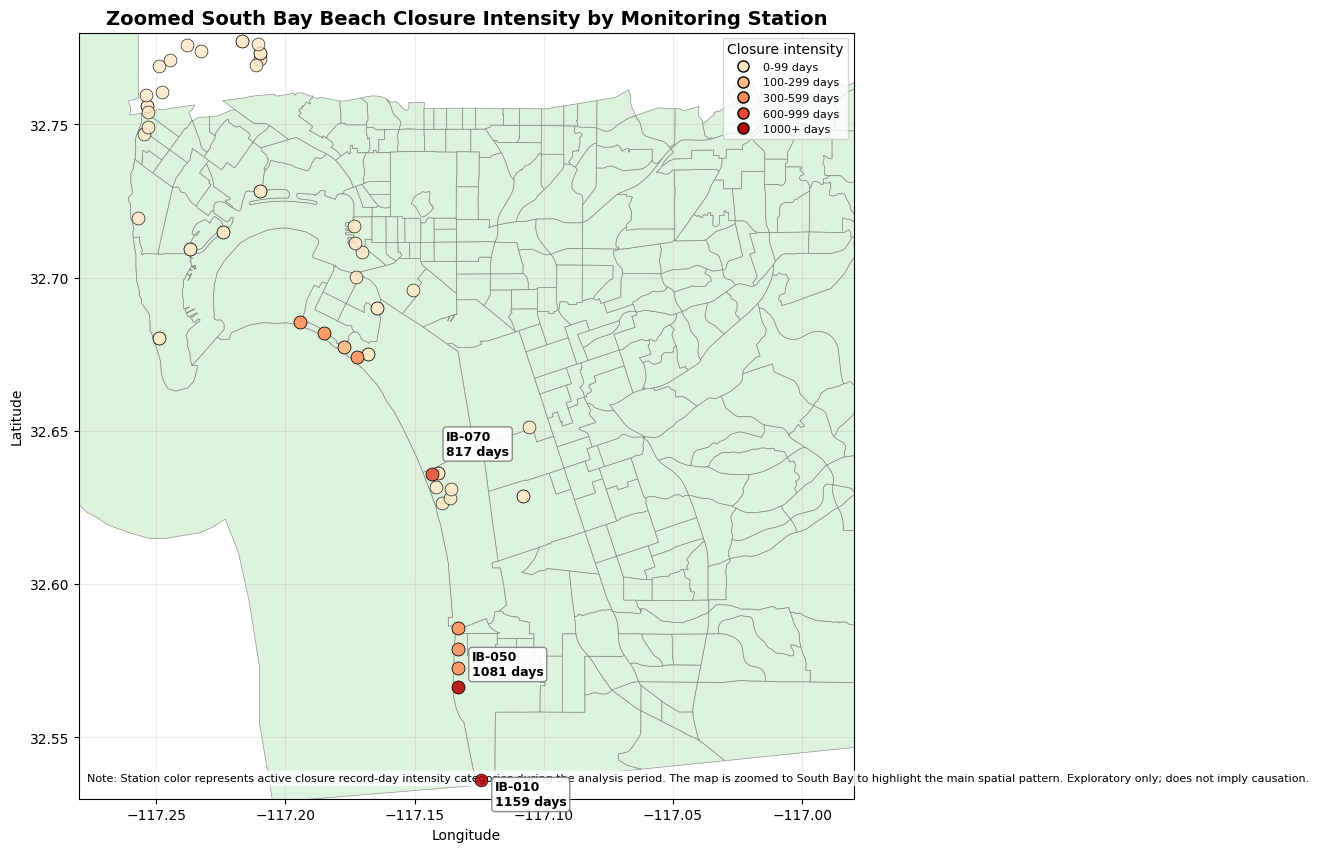

Saved figure:
/content/gdrive_maps/MyDrive/STAT596/Project596_datafiles/figures/figure_8c_notebook11_zoomed_south_bay_closure_intensity_categories_map.png
File exists: True

Saved top-3 station summary:
/content/gdrive_maps/MyDrive/STAT596/Project596_datafiles/tables/notebook11_zoomed_south_bay_top3_closure_stations.csv
File exists: True

Top 3 closure-intensity stations in zoomed South Bay map


,station_id,station_name_clean,beach_name_clean,study_group,active_closure_record_days,active_advisory_record_days,active_sewage_related_record_days
55,455,IB-010,Border Field State Park,South Bay / Tijuana River Impact,1159,1159,1159
57,459,IB-050,"Imperial Beach municipal beach, other",South Bay / Tijuana River Impact,1081,1081,1079
61,461,IB-070,Silver Strand State Beach,South Bay / Tijuana River Impact,817,817,817


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# 1. Check required objects from previous Notebook 11 cells
# ------------------------------------------------------------
required_objects = [
    "south_bay_census_wgs",
    "beach_activity_points",
    "FIGURES",
    "TABLES"
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise NameError(
        "Missing required objects from earlier Notebook 11 cells: "
        + ", ".join(missing_objects)
        + ". Run Cells 1-3 first."
    )

# ------------------------------------------------------------
# 2. Prepare beach closure layer
# ------------------------------------------------------------
beach_closure_cat = beach_activity_points.copy()

beach_closure_cat["active_closure_record_days"] = pd.to_numeric(
    beach_closure_cat["active_closure_record_days"],
    errors="coerce"
).fillna(0)

# ------------------------------------------------------------
# 3. Zoom extent for South Bay / Imperial Beach area
# ------------------------------------------------------------
xmin, xmax = -117.28, -116.98
ymin, ymax = 32.53, 32.78

beach_closure_cat = beach_closure_cat.cx[xmin:xmax, ymin:ymax].copy()
south_bay_tracts_zoom = south_bay_census_wgs.cx[xmin:xmax, ymin:ymax].copy()

# ------------------------------------------------------------
# 4. Create closure intensity categories
# ------------------------------------------------------------
closure_bins = [-0.1, 99, 299, 599, 999, np.inf]
closure_labels = [
    "0-99 days",
    "100-299 days",
    "300-599 days",
    "600-999 days",
    "1000+ days"
]

beach_closure_cat["closure_intensity_category"] = pd.cut(
    beach_closure_cat["active_closure_record_days"],
    bins=closure_bins,
    labels=closure_labels,
    include_lowest=True
)

# Color palette from lower intensity to higher intensity
category_colors = {
    "0-99 days": "#fee8c8",
    "100-299 days": "#fdbb84",
    "300-599 days": "#fc8d59",
    "600-999 days": "#e34a33",
    "1000+ days": "#b30000"
}

beach_closure_cat["category_color"] = (
    beach_closure_cat["closure_intensity_category"]
    .astype(str)
    .map(category_colors)
)

# ------------------------------------------------------------
# 5. Select top 3 stations for labeling
# ------------------------------------------------------------
top3_closure_stations = (
    beach_closure_cat
    .sort_values("active_closure_record_days", ascending=False)
    .head(3)
    .copy()
)

label_offsets = {
    "IB-010": (10, -18),
    "IB-050": (10, 8),
    "IB-070": (10, 14),
}

# ------------------------------------------------------------
# 6. Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

# South Bay census tracts as light green context
south_bay_tracts_zoom.plot(
    ax=ax,
    facecolor="#d9f2d9",
    edgecolor="gray",
    linewidth=0.5,
    alpha=0.85,
    zorder=1
)

# Plot beach stations by closure intensity category
plot_order = [
    "0-99 days",
    "100-299 days",
    "300-599 days",
    "600-999 days",
    "1000+ days"
]

for category in plot_order:
    category_data = beach_closure_cat[
        beach_closure_cat["closure_intensity_category"].astype(str) == category
    ]

    if len(category_data) == 0:
        continue

    category_data.plot(
        ax=ax,
        color=category_colors[category],
        markersize=85,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.5,
        zorder=5
    )

# ------------------------------------------------------------
# 7. Label top 3 stations
# ------------------------------------------------------------
for _, row in top3_closure_stations.iterrows():
    label = str(row.get("station_name_clean", row.get("station_name", "Beach station")))
    value = int(row["active_closure_record_days"])
    offset = label_offsets.get(label, (10, 10))

    ax.annotate(
        f"{label}\n{value} days",
        xy=(row.geometry.x, row.geometry.y),
        xytext=offset,
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        zorder=8,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="gray",
            alpha=0.9
        )
    )

# ------------------------------------------------------------
# 8. Legend
# ------------------------------------------------------------
legend_items = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="0-99 days",
        markerfacecolor=category_colors["0-99 days"],
        markeredgecolor="black",
        markersize=8
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="100-299 days",
        markerfacecolor=category_colors["100-299 days"],
        markeredgecolor="black",
        markersize=8
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="300-599 days",
        markerfacecolor=category_colors["300-599 days"],
        markeredgecolor="black",
        markersize=8
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="600-999 days",
        markerfacecolor=category_colors["600-999 days"],
        markeredgecolor="black",
        markersize=8
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="1000+ days",
        markerfacecolor=category_colors["1000+ days"],
        markeredgecolor="black",
        markersize=8
    )
]

ax.legend(
    handles=legend_items,
    loc="upper right",
    frameon=True,
    fontsize=8,
    title="Closure intensity"
)

# ------------------------------------------------------------
# 9. Titles, labels, and note
# ------------------------------------------------------------
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_title(
    "Zoomed South Bay Beach Closure Intensity by Monitoring Station",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.text(
    0.01,
    0.02,
    "Note: Station color represents active closure record-day intensity categories during the analysis period. The map is zoomed to South Bay to highlight the main spatial pattern. Exploratory only; does not imply causation.",
    transform=ax.transAxes,
    fontsize=8,
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        alpha=0.8
    )
)

ax.grid(True, alpha=0.25)

# ------------------------------------------------------------
# 10. Save outputs
# ------------------------------------------------------------
figure_path = FIGURES / "figure_8c_notebook11_zoomed_south_bay_closure_intensity_categories_map.png"
top3_path = TABLES / "notebook11_zoomed_south_bay_top3_closure_stations.csv"

fig.savefig(figure_path, dpi=300, bbox_inches="tight")
top3_closure_stations.drop(columns="geometry").to_csv(top3_path, index=False)

plt.show()

print("Saved figure:")
print(figure_path)
print("File exists:", figure_path.exists())

print("\nSaved top-3 station summary:")
print(top3_path)
print("File exists:", top3_path.exists())

print("\nTop 3 closure-intensity stations in zoomed South Bay map")
display(
    top3_closure_stations[
        [
            "station_id",
            "station_name_clean",
            "beach_name_clean",
            "study_group",
            "active_closure_record_days",
            "active_advisory_record_days",
            "active_sewage_related_record_days"
        ]
    ]
)

This map was created by combining the cleaned beach monitoring station summary with the South Bay census tract layer. Each beach monitoring station was mapped using its latitude and longitude, and the stations were colored by active closure record-day categories. The map was zoomed into the South Bay area so the main spatial pattern near Imperial Beach, Border Field, and Silver Strand would be easier to see. The top three stations with the highest closure activity were labeled to show where closure intensity was strongest.

This map relates to the project because it helps answer the spatial part of the research question: where sewage-related beach closure activity is most concentrated in South San Diego County. The pattern shows that higher closure intensity is clustered around the South Bay / Tijuana River impact area, which supports the applied question of which beaches or nearby communities may need more monitoring, alerts, cleanup, or public-health planning. This is exploratory and does not prove causation

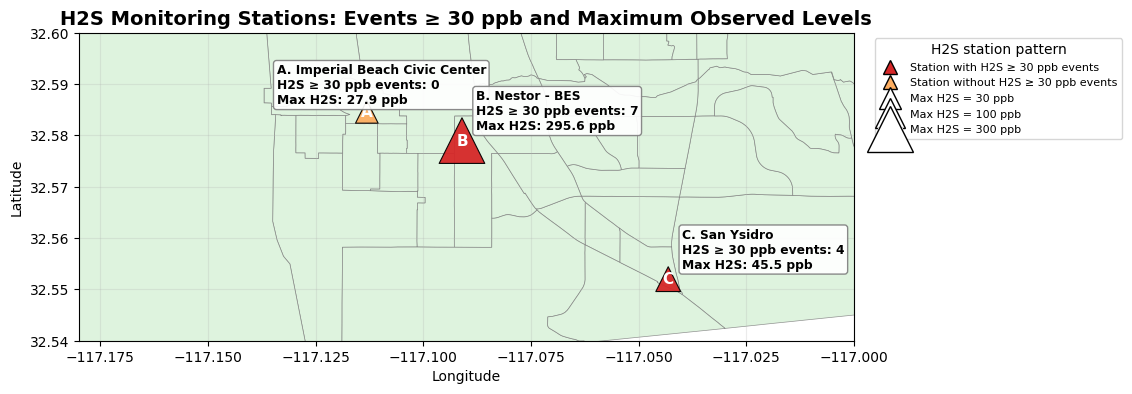

Saved figure:
/content/gdrive_maps/MyDrive/STAT596/Project596_datafiles/figures/figure_9_notebook11_h2s_station_pattern_map_no_community_labels.png
File exists: True

Saved summary table:
/content/gdrive_maps/MyDrive/STAT596/Project596_datafiles/tables/notebook11_h2s_station_pattern_summary.csv
File exists: True

Station summary


,location_clean,full_station_name,h2s_event_count,h2s_ge_10_event_count,orange_h2s_event_count,max_h2s_ppb,mean_h2s_ppb,mean_wind_speed_mph,mean_visibility_miles
0,NESTOR - BES,Nestor - BES,31,31,7,295.6,46.154839,3.022755,7.598066
1,SAN YSIDRO,San Ysidro,20,20,4,45.5,21.525000,2.963945,7.996850
2,IB CIVIC CTR,Imperial Beach Civic Center,9,9,0,27.9,16.222222,3.442402,7.013641


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# 1. Check required objects from earlier Notebook 11 cells
# ------------------------------------------------------------
required_objects = [
    "south_bay_census_wgs",
    "h2s_station_points",
    "FIGURES",
    "TABLES"
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise NameError(
        "Missing required objects from earlier Notebook 11 cells: "
        + ", ".join(missing_objects)
        + ". Run Cells 1-3 first."
    )

# ------------------------------------------------------------
# 2. Prepare H2S map layer
# ------------------------------------------------------------
h2s_map = h2s_station_points.copy()

numeric_cols = [
    "h2s_event_count",
    "h2s_ge_10_event_count",
    "orange_h2s_event_count",
    "max_h2s_ppb",
    "mean_h2s_ppb",
    "mean_wind_speed_mph",
    "mean_visibility_miles"
]

for col in numeric_cols:
    if col in h2s_map.columns:
        h2s_map[col] = pd.to_numeric(h2s_map[col], errors="coerce")

h2s_map["orange_h2s_event_count"] = h2s_map["orange_h2s_event_count"].fillna(0)
h2s_map["max_h2s_ppb"] = h2s_map["max_h2s_ppb"].fillna(0)

# ------------------------------------------------------------
# 3. Station labels and full names
# ------------------------------------------------------------
h2s_label_map = {
    "IB CIVIC CTR": "A",
    "NESTOR - BES": "B",
    "SAN YSIDRO": "C"
}

h2s_full_name_map = {
    "IB CIVIC CTR": "Imperial Beach Civic Center",
    "NESTOR - BES": "Nestor - BES",
    "SAN YSIDRO": "San Ysidro"
}

h2s_map["map_label"] = h2s_map["location_clean"].map(h2s_label_map)
h2s_map["full_station_name"] = h2s_map["location_clean"].map(h2s_full_name_map)

# Indicator: station had at least one H2S event >= 30 ppb
h2s_map["has_h2s_ge_30_event"] = h2s_map["orange_h2s_event_count"] > 0

# ------------------------------------------------------------
# 4. Marker size and color
# ------------------------------------------------------------
# Triangle size = maximum observed H2S ppb
max_ppb_value = h2s_map["max_h2s_ppb"].max()

h2s_map["marker_size"] = np.where(
    max_ppb_value > 0,
    180 + (h2s_map["max_h2s_ppb"] / max_ppb_value) * 900,
    250
)

# Triangle color = whether station had any H2S >= 30 ppb events
h2s_map["station_color"] = np.where(
    h2s_map["has_h2s_ge_30_event"],
    "#d62728",   # red
    "#fdae61"    # orange
)

# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8.5))

# South Bay census tract background
south_bay_census_wgs.plot(
    ax=ax,
    facecolor="#d9f2d9",
    edgecolor="gray",
    linewidth=0.5,
    alpha=0.85,
    zorder=1
)

# Plot H2S stations
ax.scatter(
    h2s_map.geometry.x,
    h2s_map.geometry.y,
    s=h2s_map["marker_size"],
    c=h2s_map["station_color"],
    marker="^",
    edgecolors="black",
    linewidths=0.8,
    alpha=0.95,
    zorder=5
)

# ------------------------------------------------------------
# 6. Station labels
# ------------------------------------------------------------
# Offsets tuned to reduce overlap
label_offsets = {
    "A": (-65, 6),
    "B": (10, 8),
    "C": (10, 8)
}

for _, row in h2s_map.iterrows():
    letter = row["map_label"]
    full_name = row["full_station_name"]
    n_events_ge30 = int(row["orange_h2s_event_count"])
    max_ppb = float(row["max_h2s_ppb"])
    offset = label_offsets.get(letter, (10, 8))

    # Letter inside marker
    ax.annotate(
        str(letter),
        xy=(row.geometry.x, row.geometry.y),
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white",
        zorder=7
    )

    # Label box next to marker
    ax.annotate(
        f"{letter}. {full_name}\nH2S ≥ 30 ppb events: {n_events_ge30}\nMax H2S: {max_ppb:.1f} ppb",
        xy=(row.geometry.x, row.geometry.y),
        xytext=offset,
        textcoords="offset points",
        fontsize=8.8,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="gray",
            alpha=0.92
        ),
        zorder=8
    )

# ------------------------------------------------------------
# 7. Zoom extent
# ------------------------------------------------------------
ax.set_xlim(-117.18, -117.00)
ax.set_ylim(32.54, 32.60)

# ------------------------------------------------------------
# 8. Legend
# ------------------------------------------------------------
def size_to_markersize(ppb_value, max_ppb=max_ppb_value):
    if max_ppb > 0:
        area = 180 + (ppb_value / max_ppb) * 900
    else:
        area = 250
    return np.sqrt(area)

legend_items = [
    Line2D(
        [0], [0],
        marker="^",
        color="w",
        label="Station with H2S ≥ 30 ppb events",
        markerfacecolor="#d62728",
        markeredgecolor="black",
        markersize=10
    ),
    Line2D(
        [0], [0],
        marker="^",
        color="w",
        label="Station without H2S ≥ 30 ppb events",
        markerfacecolor="#fdae61",
        markeredgecolor="black",
        markersize=10
    ),
    Line2D(
        [0], [0],
        marker="^",
        color="w",
        label="Max H2S = 30 ppb",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=size_to_markersize(30)
    ),
    Line2D(
        [0], [0],
        marker="^",
        color="w",
        label="Max H2S = 100 ppb",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=size_to_markersize(100)
    ),
    Line2D(
        [0], [0],
        marker="^",
        color="w",
        label="Max H2S = 300 ppb",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=size_to_markersize(300)
    )
]

ax.legend(
    handles=legend_items,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=True,
    fontsize=8,
    title="H2S station pattern"
)

# ------------------------------------------------------------
# 9. Titles and axis labels
# ------------------------------------------------------------
ax.set_title(
    "H2S Monitoring Stations: Events ≥ 30 ppb and Maximum Observed Levels",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.25)



# ------------------------------------------------------------
# 11. Save figure and summary table
# ------------------------------------------------------------
figure_path = FIGURES / "figure_9_notebook11_h2s_station_pattern_map_no_community_labels.png"
summary_path = TABLES / "notebook11_h2s_station_pattern_summary.csv"

fig.savefig(figure_path, dpi=300, bbox_inches="tight")

summary_cols = [
    "location_clean",
    "full_station_name",
    "h2s_event_count",
    "h2s_ge_10_event_count",
    "orange_h2s_event_count",
    "max_h2s_ppb",
    "mean_h2s_ppb",
    "mean_wind_speed_mph",
    "mean_visibility_miles"
]

h2s_map[summary_cols].sort_values(
    "max_h2s_ppb", ascending=False
).to_csv(summary_path, index=False)

plt.show()

print("Saved figure:")
print(figure_path)
print("File exists:", figure_path.exists())

print("\nSaved summary table:")
print(summary_path)
print("File exists:", summary_path.exists())

print("\nStation summary")
display(
    h2s_map[summary_cols]
    .sort_values("max_h2s_ppb", ascending=False)
    .reset_index(drop=True)
)

Figure 9. H2S monitoring stations: events ≥ 30 ppb and maximum observed levels. Triangle color shows whether each station recorded any H2S events at or above 30 ppb, and triangle size represents the maximum observed H2S concentration in the project subset. Nestor - BES had the strongest H2S pattern, with 7 events ≥ 30 ppb and a maximum value of 295.6 ppb. San Ysidro also recorded elevated events, while Imperial Beach Civic Center did not reach the ≥30 ppb threshold in this subset. This figure supports the air-quality side of the project and helps show where elevated H2S activity was strongest across South Bay communities. The analysis is exploratory and does not imply causation.

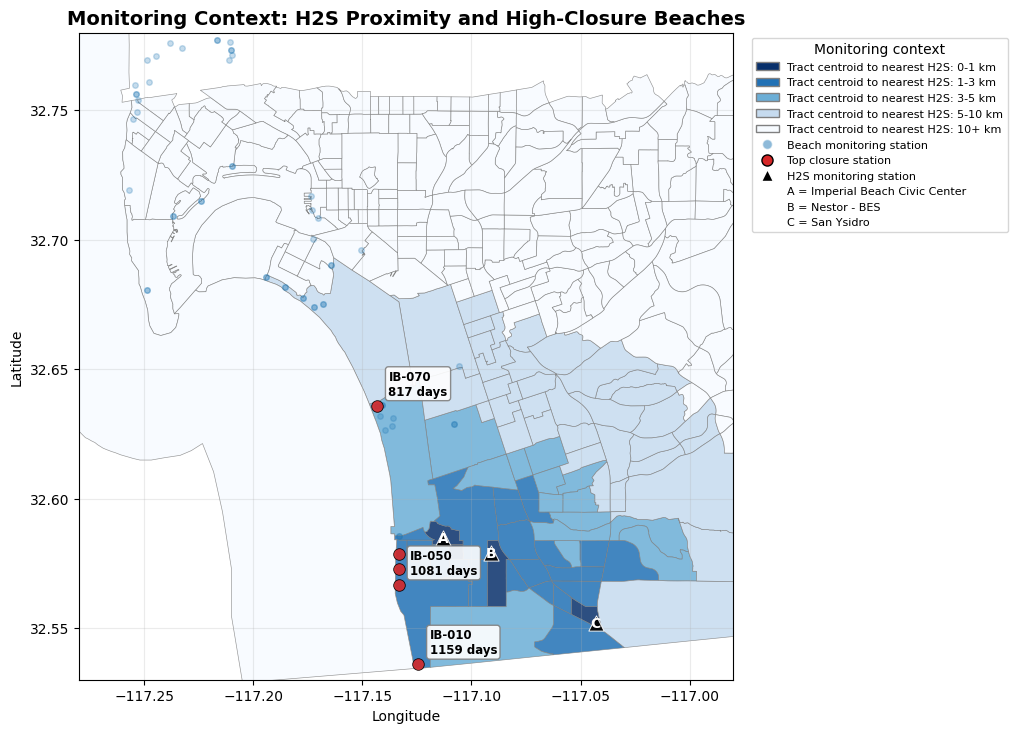

Saved figure:
/content/gdrive_maps/MyDrive/STAT596/Project596_datafiles/figures/figure_10_notebook11_monitoring_context_h2s_proximity_high_closure_beaches.png
File exists: True

Saved tract-level proximity summary:
/content/gdrive_maps/MyDrive/STAT596/Project596_datafiles/tables/notebook11_community_proximity_monitoring_context_summary.csv
File exists: True

Saved tract-count summary:
/content/gdrive_maps/MyDrive/STAT596/Project596_datafiles/tables/notebook11_h2s_proximity_tract_count_summary.csv
File exists: True

Tract-count summary by distance to nearest H2S monitoring station


,h2s_proximity_category,number_of_tracts,legend_definition
0,0-1 km,4,Tract centroid distance to nearest H2S monitor...
1,1-3 km,20,Tract centroid distance to nearest H2S monitor...
2,3-5 km,15,Tract centroid distance to nearest H2S monitor...
3,5-10 km,37,Tract centroid distance to nearest H2S monitor...
4,10+ km,187,Tract centroid distance to nearest H2S monitor...



Closest tracts to H2S monitoring stations


,tract_index,dist_to_nearest_h2s_km,dist_to_top_closure_beach_km,h2s_proximity_category
168,168,0.158085,2.069194,0-1 km
257,257,0.567827,7.546804,0-1 km
160,160,0.798998,2.444000,0-1 km
156,156,0.984865,4.205109,0-1 km
159,159,1.000515,1.792763,1-3 km
255,255,1.085736,6.827773,1-3 km
121,121,1.138782,0.876031,1-3 km
167,167,1.226984,1.001606,1-3 km
259,259,1.266701,5.149516,1-3 km
88,88,1.411862,3.404830,1-3 km



Top closure beach stations shown on map


,station_id,station_name_clean,beach_name_clean,study_group,active_closure_record_days
55,455,IB-010,Border Field State Park,South Bay / Tijuana River Impact,1159
57,459,IB-050,"Imperial Beach municipal beach, other",South Bay / Tijuana River Impact,1081
61,461,IB-070,Silver Strand State Beach,South Bay / Tijuana River Impact,817
2,319,EH-010,"Imperial Beach municipal beach, other",South Bay / Tijuana River Impact,484
4,322,EH-030,Imperial Beach pier area,South Bay / Tijuana River Impact,480


In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from shapely.ops import unary_union

# ------------------------------------------------------------
# 1. Check required objects from earlier Notebook 11 cells
# ------------------------------------------------------------
required_objects = [
    "south_bay_census_wgs",
    "h2s_station_points",
    "beach_activity_points",
    "FIGURES",
    "TABLES"
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise NameError(
        "Missing required objects from earlier Notebook 11 cells: "
        + ", ".join(missing_objects)
        + ". Run the earlier Notebook 11 setup cells first."
    )

# ------------------------------------------------------------
# 2. Copy layers
# ------------------------------------------------------------
tracts_wgs = south_bay_census_wgs.copy()
h2s_wgs = h2s_station_points.copy()
beach_wgs = beach_activity_points.copy()

# Make sure layers have CRS
if tracts_wgs.crs is None:
    tracts_wgs = tracts_wgs.set_crs(epsg=4326)

if h2s_wgs.crs is None:
    h2s_wgs = h2s_wgs.set_crs(epsg=4326)

if beach_wgs.crs is None:
    beach_wgs = beach_wgs.set_crs(epsg=4326)

# ------------------------------------------------------------
# 3. Project to California Albers for distance calculations
# ------------------------------------------------------------
# EPSG:3310 is appropriate for California distance/area work in meters.
distance_crs = "EPSG:3310"

tracts_proj = tracts_wgs.to_crs(distance_crs).copy()
h2s_proj = h2s_wgs.to_crs(distance_crs).copy()
beach_proj = beach_wgs.to_crs(distance_crs).copy()

# ------------------------------------------------------------
# 4. Prepare beach closure intensity layer
# ------------------------------------------------------------
beach_proj["active_closure_record_days"] = pd.to_numeric(
    beach_proj["active_closure_record_days"],
    errors="coerce"
).fillna(0)

# Focus on high-closure stations for map labels
top_beach_stations_proj = (
    beach_proj
    .sort_values("active_closure_record_days", ascending=False)
    .head(5)
    .copy()
)

top_beach_stations_wgs = top_beach_stations_proj.to_crs(epsg=4326)

# ------------------------------------------------------------
# 5. Calculate tract-centroid distance to nearest H2S station
# ------------------------------------------------------------
h2s_union = unary_union(h2s_proj.geometry)

tracts_proj["centroid_geom"] = tracts_proj.geometry.centroid

tracts_proj["dist_to_nearest_h2s_km"] = (
    tracts_proj["centroid_geom"].distance(h2s_union) / 1000
)

# Also calculate distance to nearest top beach closure station for summary context
top_beach_union = unary_union(top_beach_stations_proj.geometry)

tracts_proj["dist_to_top_closure_beach_km"] = (
    tracts_proj["centroid_geom"].distance(top_beach_union) / 1000
)

# Bring distance fields back to WGS layer for plotting
tracts_wgs["dist_to_nearest_h2s_km"] = tracts_proj["dist_to_nearest_h2s_km"].values
tracts_wgs["dist_to_top_closure_beach_km"] = tracts_proj["dist_to_top_closure_beach_km"].values

# ------------------------------------------------------------
# 6. Create H2S proximity categories
# ------------------------------------------------------------
distance_bins = [0, 1, 3, 5, 10, np.inf]

distance_labels = [
    "0-1 km",
    "1-3 km",
    "3-5 km",
    "5-10 km",
    "10+ km"
]

tracts_wgs["h2s_proximity_category"] = pd.cut(
    tracts_wgs["dist_to_nearest_h2s_km"],
    bins=distance_bins,
    labels=distance_labels,
    include_lowest=True
)

proximity_colors = {
    "0-1 km": "#08306b",
    "1-3 km": "#2171b5",
    "3-5 km": "#6baed6",
    "5-10 km": "#c6dbef",
    "10+ km": "#f7fbff"
}

# ------------------------------------------------------------
# 7. H2S station labels
# ------------------------------------------------------------
h2s_label_map = {
    "IB CIVIC CTR": "A",
    "NESTOR - BES": "B",
    "SAN YSIDRO": "C"
}

h2s_full_name_map = {
    "IB CIVIC CTR": "Imperial Beach Civic Center",
    "NESTOR - BES": "Nestor - BES",
    "SAN YSIDRO": "San Ysidro"
}

h2s_wgs["map_label"] = h2s_wgs["location_clean"].map(h2s_label_map)
h2s_wgs["full_station_name"] = h2s_wgs["location_clean"].map(h2s_full_name_map)

# ------------------------------------------------------------
# 8. Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 8.5))

# Plot tracts by distance category
for category in distance_labels:
    subset = tracts_wgs[
        tracts_wgs["h2s_proximity_category"].astype(str) == category
    ]

    if len(subset) == 0:
        continue

    subset.plot(
        ax=ax,
        facecolor=proximity_colors[category],
        edgecolor="gray",
        linewidth=0.45,
        alpha=0.85,
        zorder=1
    )

# Plot all beach monitoring stations lightly for context
beach_wgs.plot(
    ax=ax,
    color="#1f77b4",
    markersize=16,
    alpha=0.25,
    zorder=2
)

# Plot top closure beach stations
top_beach_stations_wgs.plot(
    ax=ax,
    color="#d62728",
    markersize=70,
    edgecolor="black",
    linewidth=0.6,
    alpha=0.9,
    zorder=4
)

# Label top 3 beach stations only
top3_beach_labels = (
    top_beach_stations_wgs
    .sort_values("active_closure_record_days", ascending=False)
    .head(3)
)

for _, row in top3_beach_labels.iterrows():
    station_label = str(row.get("station_name_clean", row.get("station_name", "Beach station")))
    closure_days = int(row["active_closure_record_days"])

    ax.annotate(
        f"{station_label}\n{closure_days} days",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=8.5,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="gray",
            alpha=0.9
        ),
        zorder=6
    )

# Plot H2S stations
h2s_wgs.plot(
    ax=ax,
    marker="^",
    color="black",
    markersize=120,
    edgecolor="white",
    linewidth=0.7,
    alpha=0.95,
    zorder=5
)

# Label H2S stations with A/B/C
for _, row in h2s_wgs.iterrows():
    ax.annotate(
        str(row["map_label"]),
        xy=(row.geometry.x, row.geometry.y),
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="white",
        zorder=7
    )

# ------------------------------------------------------------
# 9. Zoom extent
# ------------------------------------------------------------
ax.set_xlim(-117.28, -116.98)
ax.set_ylim(32.53, 32.78)

# ------------------------------------------------------------
# 10. Legend with more precise wording
# ------------------------------------------------------------
legend_items = []

for category in distance_labels:
    legend_items.append(
        Patch(
            facecolor=proximity_colors[category],
            edgecolor="gray",
            label=f"Tract centroid to nearest H2S: {category}"
        )
    )

legend_items.extend([
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Beach monitoring station",
        markerfacecolor="#1f77b4",
        markersize=7,
        alpha=0.5
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Top closure station",
        markerfacecolor="#d62728",
        markeredgecolor="black",
        markersize=8
    ),
    Line2D(
        [0], [0],
        marker="^",
        color="w",
        label="H2S monitoring station",
        markerfacecolor="black",
        markeredgecolor="white",
        markersize=9
    ),
    Line2D([0], [0], linestyle="None", label="A = Imperial Beach Civic Center"),
    Line2D([0], [0], linestyle="None", label="B = Nestor - BES"),
    Line2D([0], [0], linestyle="None", label="C = San Ysidro")
])

ax.legend(
    handles=legend_items,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=True,
    fontsize=8,
    title="Monitoring context"
)

# ------------------------------------------------------------
# 11. Shorter title and axis labels
# ------------------------------------------------------------
ax.set_title(
    "Monitoring Context: H2S Proximity and High-Closure Beaches",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.25)

# Make room for outside legend
fig.subplots_adjust(right=0.72)

# ------------------------------------------------------------
# 12. Save figure, tract-level summary, and tract-count summary
# ------------------------------------------------------------
figure_path = FIGURES / "figure_10_notebook11_monitoring_context_h2s_proximity_high_closure_beaches.png"
tract_summary_path = TABLES / "notebook11_community_proximity_monitoring_context_summary.csv"
tract_count_path = TABLES / "notebook11_h2s_proximity_tract_count_summary.csv"

fig.savefig(figure_path, dpi=300, bbox_inches="tight")

# Build tract-level summary table
possible_tract_id_cols = [
    "GEOID",
    "GEOID20",
    "TRACTCE",
    "TRACTCE20",
    "NAMELSAD",
    "NAME"
]

existing_tract_id_cols = [
    col for col in possible_tract_id_cols
    if col in tracts_wgs.columns
]

tract_summary = tracts_wgs.copy()
tract_summary["tract_index"] = tract_summary.index

summary_cols = (
    ["tract_index"]
    + existing_tract_id_cols
    + [
        "dist_to_nearest_h2s_km",
        "dist_to_top_closure_beach_km",
        "h2s_proximity_category"
    ]
)

tract_summary[summary_cols].to_csv(tract_summary_path, index=False)

# Create tract-count summary table by H2S proximity category
tract_count_summary = (
    tract_summary["h2s_proximity_category"]
    .astype(str)
    .value_counts()
    .reindex(distance_labels, fill_value=0)
    .reset_index()
)

tract_count_summary.columns = [
    "h2s_proximity_category",
    "number_of_tracts"
]

tract_count_summary["legend_definition"] = (
    "Tract centroid distance to nearest H2S monitoring station"
)

tract_count_summary.to_csv(tract_count_path, index=False)

plt.show()

print("Saved figure:")
print(figure_path)
print("File exists:", figure_path.exists())

print("\nSaved tract-level proximity summary:")
print(tract_summary_path)
print("File exists:", tract_summary_path.exists())

print("\nSaved tract-count summary:")
print(tract_count_path)
print("File exists:", tract_count_path.exists())

print("\nTract-count summary by distance to nearest H2S monitoring station")
display(tract_count_summary)

print("\nClosest tracts to H2S monitoring stations")
display(
    tract_summary[summary_cols]
    .sort_values("dist_to_nearest_h2s_km")
    .head(10)
)

print("\nTop closure beach stations shown on map")
display(
    top_beach_stations_wgs[
        [
            "station_id",
            "station_name_clean",
            "beach_name_clean",
            "study_group",
            "active_closure_record_days"
        ]
    ]
    .sort_values("active_closure_record_days", ascending=False)
)

This map was created by calculating the distance from each South Bay census tract centroid to the nearest H2S monitoring station. Census tracts were grouped into distance categories, with darker blue colors representing closer proximity. The map also includes the beach monitoring stations with the highest active closure record-days. Together, these layers show where air-quality monitoring, nearby communities, and repeated beach closure activity overlap spatially. This supports the project’s applied focus by identifying areas where monitoring, alerts, cleanup, or public-health planning may be especially relevant. The map is exploratory and does not imply causation.

In [ ]:
from pathlib import Path
from datetime import datetime
import pandas as pd

# ------------------------------------------------------------
# 1. Check required folders
# ------------------------------------------------------------
required_objects = ["FIGURES", "TABLES"]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise NameError(
        "Missing required folder objects: "
        + ", ".join(missing_objects)
        + ". Run the Notebook 11 setup cells first."
    )

FIGURES = Path(FIGURES)
TABLES = Path(TABLES)

FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Define expected Notebook 11 outputs
# ------------------------------------------------------------
expected_outputs = [
    {
        "output_type": "figure",
        "file_name": "figure_7_notebook11_study_area_map.png",
        "folder": FIGURES,
        "paper_role": "Study area context map",
        "recommended_for_final_paper": "Yes",
        "description": "Shows South Bay census tracts, beach monitoring stations, and H2S monitoring stations."
    },
    {
        "output_type": "figure",
        "file_name": "figure_8_notebook11_beach_closure_intensity_map.png",
        "folder": FIGURES,
        "paper_role": "County/coastal beach closure context map",
        "recommended_for_final_paper": "Optional",
        "description": "Shows beach closure intensity across the larger monitoring network."
    },
    {
        "output_type": "figure",
        "file_name": "figure_8c_notebook11_zoomed_south_bay_closure_intensity_categories_map.png",
        "folder": FIGURES,
        "paper_role": "Zoomed South Bay closure intensity map",
        "recommended_for_final_paper": "Yes",
        "description": "Shows South Bay beach monitoring stations colored by active closure record-day category."
    },
    {
        "output_type": "figure",
        "file_name": "figure_9_notebook11_h2s_station_pattern_map_no_community_labels.png",
        "folder": FIGURES,
        "paper_role": "H2S station pattern map",
        "recommended_for_final_paper": "Yes",
        "description": "Shows H2S monitoring stations, H2S events at or above 30 ppb, and maximum observed H2S levels."
    },
    {
        "output_type": "figure",
        "file_name": "figure_10_notebook11_monitoring_context_h2s_proximity_high_closure_beaches.png",
        "folder": FIGURES,
        "paper_role": "Monitoring context and community proximity map",
        "recommended_for_final_paper": "Yes",
        "description": "Shows tract-centroid proximity to nearest H2S station and high-closure beach stations."
    },
    {
        "output_type": "table",
        "file_name": "notebook11_beach_station_map_summary.csv",
        "folder": TABLES,
        "paper_role": "Beach station summary table",
        "recommended_for_final_paper": "Supporting",
        "description": "Station-level beach closure/advisory summary used for map creation."
    },
    {
        "output_type": "table",
        "file_name": "notebook11_h2s_station_map_summary.csv",
        "folder": TABLES,
        "paper_role": "H2S station summary table",
        "recommended_for_final_paper": "Supporting",
        "description": "Station-level H2S event and weather summary used for map creation."
    },
    {
        "output_type": "table",
        "file_name": "notebook11_zoomed_south_bay_top3_closure_stations.csv",
        "folder": TABLES,
        "paper_role": "Top closure stations table",
        "recommended_for_final_paper": "Supporting",
        "description": "Top South Bay beach stations by active closure record-days."
    },
    {
        "output_type": "table",
        "file_name": "notebook11_h2s_station_pattern_summary.csv",
        "folder": TABLES,
        "paper_role": "H2S station pattern summary",
        "recommended_for_final_paper": "Supporting",
        "description": "Summary table for H2S events, maximum H2S, mean H2S, wind speed, and visibility."
    },
    {
        "output_type": "table",
        "file_name": "notebook11_community_proximity_monitoring_context_summary.csv",
        "folder": TABLES,
        "paper_role": "Tract-level proximity summary",
        "recommended_for_final_paper": "Supporting",
        "description": "Tract-level distances to nearest H2S station and top closure beach station."
    },
    {
        "output_type": "table",
        "file_name": "notebook11_h2s_proximity_tract_count_summary.csv",
        "folder": TABLES,
        "paper_role": "Tract-count summary by H2S proximity",
        "recommended_for_final_paper": "Yes or Supporting",
        "description": "Counts census tracts by distance category to nearest H2S monitoring station."
    }
]

# ------------------------------------------------------------
# 3. Build inventory with existence checks
# ------------------------------------------------------------
inventory_rows = []

for item in expected_outputs:
    path = item["folder"] / item["file_name"]
    exists = path.exists()

    file_size_kb = round(path.stat().st_size / 1024, 2) if exists else None
    modified_time = (
        datetime.fromtimestamp(path.stat().st_mtime).strftime("%Y-%m-%d %H:%M:%S")
        if exists else None
    )

    inventory_rows.append({
        "output_type": item["output_type"],
        "file_name": item["file_name"],
        "file_path": str(path),
        "exists": exists,
        "file_size_kb": file_size_kb,
        "modified_time": modified_time,
        "paper_role": item["paper_role"],
        "recommended_for_final_paper": item["recommended_for_final_paper"],
        "description": item["description"]
    })

notebook11_inventory = pd.DataFrame(inventory_rows)

# ------------------------------------------------------------
# 4. Create final-paper figure caption helper table
# ------------------------------------------------------------
caption_rows = [
    {
        "suggested_figure_number": "Figure 7",
        "file_name": "figure_7_notebook11_study_area_map.png",
        "suggested_caption": (
            "Study area map of South San Diego County monitoring locations. "
            "The map shows South Bay census tracts, beach monitoring stations, and H2S monitoring stations "
            "used in the exploratory analysis."
        ),
        "main_point_for_results_section": (
            "The datasets are spatially connected across South Bay communities, beaches, and air-quality monitoring locations."
        )
    },
    {
        "suggested_figure_number": "Figure 8",
        "file_name": "figure_8c_notebook11_zoomed_south_bay_closure_intensity_categories_map.png",
        "suggested_caption": (
            "Zoomed South Bay beach closure intensity by monitoring station. "
            "Beach stations are colored by active closure record-day category, and the highest-closure stations are labeled."
        ),
        "main_point_for_results_section": (
            "Closure activity is concentrated near the South Bay / Tijuana River impact area, especially around Imperial Beach and Border Field."
        )
    },
    {
        "suggested_figure_number": "Figure 9",
        "file_name": "figure_9_notebook11_h2s_station_pattern_map_no_community_labels.png",
        "suggested_caption": (
            "H2S monitoring stations showing events at or above 30 ppb and maximum observed H2S levels. "
            "Triangle color shows whether each station recorded H2S events at or above 30 ppb, and triangle size represents maximum observed H2S."
        ),
        "main_point_for_results_section": (
            "Nestor - BES had the strongest H2S pattern in the project subset, followed by San Ysidro."
        )
    },
    {
        "suggested_figure_number": "Figure 10",
        "file_name": "figure_10_notebook11_monitoring_context_h2s_proximity_high_closure_beaches.png",
        "suggested_caption": (
            "Monitoring context map showing tract-centroid proximity to the nearest H2S monitoring station and high-closure beach stations. "
            "Darker blue tracts are closer to H2S monitoring stations, while red points show beach stations with the highest closure record-days."
        ),
        "main_point_for_results_section": (
            "Nearby communities, H2S monitoring locations, and repeated beach closure activity overlap spatially in the South Bay area."
        )
    }
]

notebook11_caption_table = pd.DataFrame(caption_rows)

# ------------------------------------------------------------
# 5. Save inventory outputs
# ------------------------------------------------------------
inventory_path = TABLES / "notebook11_output_inventory.csv"
caption_path = TABLES / "notebook11_final_figure_caption_helper.csv"

notebook11_inventory.to_csv(inventory_path, index=False)
notebook11_caption_table.to_csv(caption_path, index=False)

# ------------------------------------------------------------
# 6. QA summary
# ------------------------------------------------------------
total_expected = len(notebook11_inventory)
total_found = notebook11_inventory["exists"].sum()
total_missing = total_expected - total_found

print("=" * 70)
print("Notebook 11 output inventory QA")
print("=" * 70)
print(f"Expected outputs: {total_expected}")
print(f"Found outputs: {total_found}")
print(f"Missing outputs: {total_missing}")

print("\nSaved inventory:")
print(inventory_path)
print("File exists:", inventory_path.exists())

print("\nSaved final-paper caption helper:")
print(caption_path)
print("File exists:", caption_path.exists())

print("\nMissing outputs, if any:")
missing_outputs = notebook11_inventory[notebook11_inventory["exists"] == False]

if len(missing_outputs) == 0:
    print("No missing expected outputs.")
else:
    display(missing_outputs[["output_type", "file_name", "file_path"]])

print("\nNotebook 11 output inventory")
display(notebook11_inventory)

print("\nFinal-paper figure caption helper")
display(notebook11_caption_table)

# ------------------------------------------------------------
# 7. Show recommended final-paper figures only
# ------------------------------------------------------------
print("\nRecommended final-paper figures from Notebook 11")
display(
    notebook11_inventory[
        (notebook11_inventory["output_type"] == "figure")
        & (notebook11_inventory["recommended_for_final_paper"] == "Yes")
    ][
        [
            "file_name",
            "exists",
            "paper_role",
            "description",
            "file_path"
        ]
    ]
)

Notebook 11 output inventory QA
Expected outputs: 11
Found outputs: 11
Missing outputs: 0

Saved inventory:
/content/gdrive_maps/MyDrive/STAT596/Project596_datafiles/tables/notebook11_output_inventory.csv
File exists: True

Saved final-paper caption helper:
/content/gdrive_maps/MyDrive/STAT596/Project596_datafiles/tables/notebook11_final_figure_caption_helper.csv
File exists: True

Missing outputs, if any:
No missing expected outputs.

Notebook 11 output inventory


,output_type,file_name,file_path,exists,file_size_kb,modified_time,paper_role,recommended_for_final_paper,description
0,figure,figure_7_notebook11_study_area_map.png,/content/gdrive_maps/MyDrive/STAT596/Project59...,True,886.95,2026-05-04 14:28:05,Study area context map,Yes,"Shows South Bay census tracts, beach monitorin..."
1,figure,figure_8_notebook11_beach_closure_intensity_ma...,/content/gdrive_maps/MyDrive/STAT596/Project59...,True,929.17,2026-05-04 14:32:02,County/coastal beach closure context map,Optional,Shows beach closure intensity across the large...
2,figure,figure_8c_notebook11_zoomed_south_bay_closure_...,/content/gdrive_maps/MyDrive/STAT596/Project59...,True,1007.59,2026-05-04 14:50:59,Zoomed South Bay closure intensity map,Yes,Shows South Bay beach monitoring stations colo...
3,figure,figure_9_notebook11_h2s_station_pattern_map_no...,/content/gdrive_maps/MyDrive/STAT596/Project59...,True,369.49,2026-05-04 15:14:33,H2S station pattern map,Yes,"Shows H2S monitoring stations, H2S events at o..."
4,figure,figure_10_notebook11_monitoring_context_h2s_pr...,/content/gdrive_maps/MyDrive/STAT596/Project59...,True,858.83,2026-05-04 15:25:32,Monitoring context and community proximity map,Yes,Shows tract-centroid proximity to nearest H2S ...
5,table,notebook11_beach_station_map_summary.csv,/content/gdrive_maps/MyDrive/STAT596/Project59...,True,16.84,2026-05-04 14:13:50,Beach station summary table,Supporting,Station-level beach closure/advisory summary u...
6,table,notebook11_h2s_station_map_summary.csv,/content/gdrive_maps/MyDrive/STAT596/Project59...,True,0.50,2026-05-04 14:13:50,H2S station summary table,Supporting,Station-level H2S event and weather summary us...
7,table,notebook11_zoomed_south_bay_top3_closure_stati...,/content/gdrive_maps/MyDrive/STAT596/Project59...,True,0.92,2026-05-04 14:50:59,Top closure stations table,Supporting,Top South Bay beach stations by active closure...
8,table,notebook11_h2s_station_pattern_summary.csv,/content/gdrive_maps/MyDrive/STAT596/Project59...,True,0.43,2026-05-04 15:14:33,H2S station pattern summary,Supporting,"Summary table for H2S events, maximum H2S, mea..."
9,table,notebook11_community_proximity_monitoring_cont...,/content/gdrive_maps/MyDrive/STAT596/Project59...,True,12.32,2026-05-04 15:25:32,Tract-level proximity summary,Supporting,Tract-level distances to nearest H2S station a...



Final-paper figure caption helper


,suggested_figure_number,file_name,suggested_caption,main_point_for_results_section
0,Figure 7,figure_7_notebook11_study_area_map.png,Study area map of South San Diego County monit...,The datasets are spatially connected across So...
1,Figure 8,figure_8c_notebook11_zoomed_south_bay_closure_...,Zoomed South Bay beach closure intensity by mo...,Closure activity is concentrated near the Sout...
2,Figure 9,figure_9_notebook11_h2s_station_pattern_map_no...,H2S monitoring stations showing events at or a...,Nestor - BES had the strongest H2S pattern in ...
3,Figure 10,figure_10_notebook11_monitoring_context_h2s_pr...,Monitoring context map showing tract-centroid ...,"Nearby communities, H2S monitoring locations, ..."



Recommended final-paper figures from Notebook 11


,file_name,exists,paper_role,description,file_path
0,figure_7_notebook11_study_area_map.png,True,Study area context map,"Shows South Bay census tracts, beach monitorin...",/content/gdrive_maps/MyDrive/STAT596/Project59...
2,figure_8c_notebook11_zoomed_south_bay_closure_...,True,Zoomed South Bay closure intensity map,Shows South Bay beach monitoring stations colo...,/content/gdrive_maps/MyDrive/STAT596/Project59...
3,figure_9_notebook11_h2s_station_pattern_map_no...,True,H2S station pattern map,"Shows H2S monitoring stations, H2S events at o...",/content/gdrive_maps/MyDrive/STAT596/Project59...
4,figure_10_notebook11_monitoring_context_h2s_pr...,True,Monitoring context and community proximity map,Shows tract-centroid proximity to nearest H2S ...,/content/gdrive_maps/MyDrive/STAT596/Project59...
